In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load training dataset

df = pd.read_csv("train.csv", index_col = "Id")

**Overview of training data**

In [3]:
# Data overview

print("df shape: ", df.shape)
print("Missing values: \n", df.isnull().sum().sort_values(ascending=False))
print("Data types: \n", df.dtypes.value_counts())
df.head()


df shape:  (1460, 80)
Missing values: 
 PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 80, dtype: int64
Data types: 
 str        43
int64      34
float64     3
Name: count, dtype: int64


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


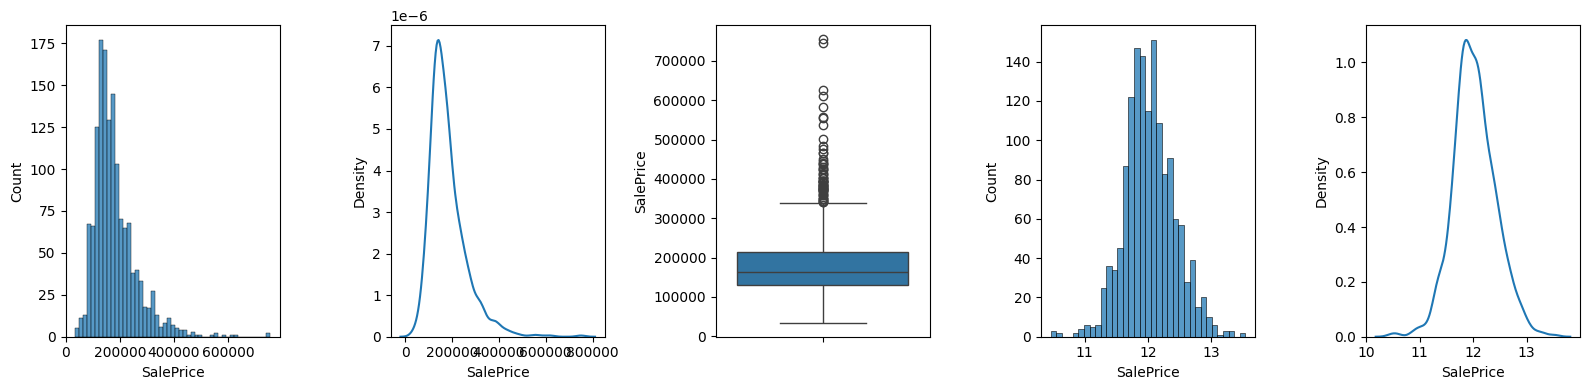

In [4]:
# Target variable exploration

fig, axes = plt.subplots(ncols=5, figsize = (16, 4)) 

sns.histplot(df["SalePrice"], ax=axes[0])
sns.kdeplot(df["SalePrice"], ax=axes[1])
sns.boxplot(df["SalePrice"], ax=axes[2])
sns.histplot(np.log1p(df["SalePrice"]), ax=axes[3])
sns.kdeplot(np.log1p(df["SalePrice"]), ax=axes[4])

plt.tight_layout()
plt.show()

Since house prices appear normally distributed under log transform, the new target variable will be log(SalePrice), to be converted back to SalePrice after prediction.

In [5]:
# Convert features to categorical

df["MoSold"] = df["MoSold"].astype("str")
df["MSSubClass"] = df["MSSubClass"].astype("str")

**Missing values**

In [6]:
# Missing value analysis

missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [7]:
# Fill missing with None

cols_to_fill_with_NA = ["PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType", "FireplaceQu", "GarageType", "GarageQual", "GarageCond", "BsmtExposure", "BsmtFinType2", "BsmtQual", "BsmtCond", "BsmtFinType1", "Electrical", "GarageFinish"]

df[cols_to_fill_with_NA] = df[cols_to_fill_with_NA].fillna("None")

In [8]:
# Fill missing lot frontage with median for neighbourhood

df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

In [10]:
# Fill MasVnrArea by median of MasVnrType

df['MasVnrArea'] = df['MasVnrArea'].fillna(
    df.groupby('MasVnrType')['MasVnrArea'].transform('median')
)

In [11]:
# Fix missing garage age by creating new features, and filling

df["has_garage"] = df["GarageYrBlt"].notnull().astype(bool)
df["garage_age"] = df["YrSold"] - df["GarageYrBlt"]
df["garage_age"] = df["garage_age"].fillna(0)

df = df.drop(columns="GarageYrBlt")

# Check working correctly, false garage should have 0 age, true garage has actual age.

df[["has_garage", "garage_age"]].sample(10)

,has_garage,garage_age
Id,,
658,True,77.0
651,True,1.0
902,True,41.0
1323,True,18.0
1357,True,42.0
844,False,0.0
829,True,42.0
455,True,30.0
1295,True,49.0


In [12]:
# Check missingess

df.isnull().sum().sum()

np.int64(0)

**Numeric features**

In [13]:
# Numeric feature distrubtion

numeric_cols = df.drop(columns = "SalePrice").select_dtypes(np.number).columns

print("Numeric columns: ", len(numeric_cols))

Numeric columns:  34


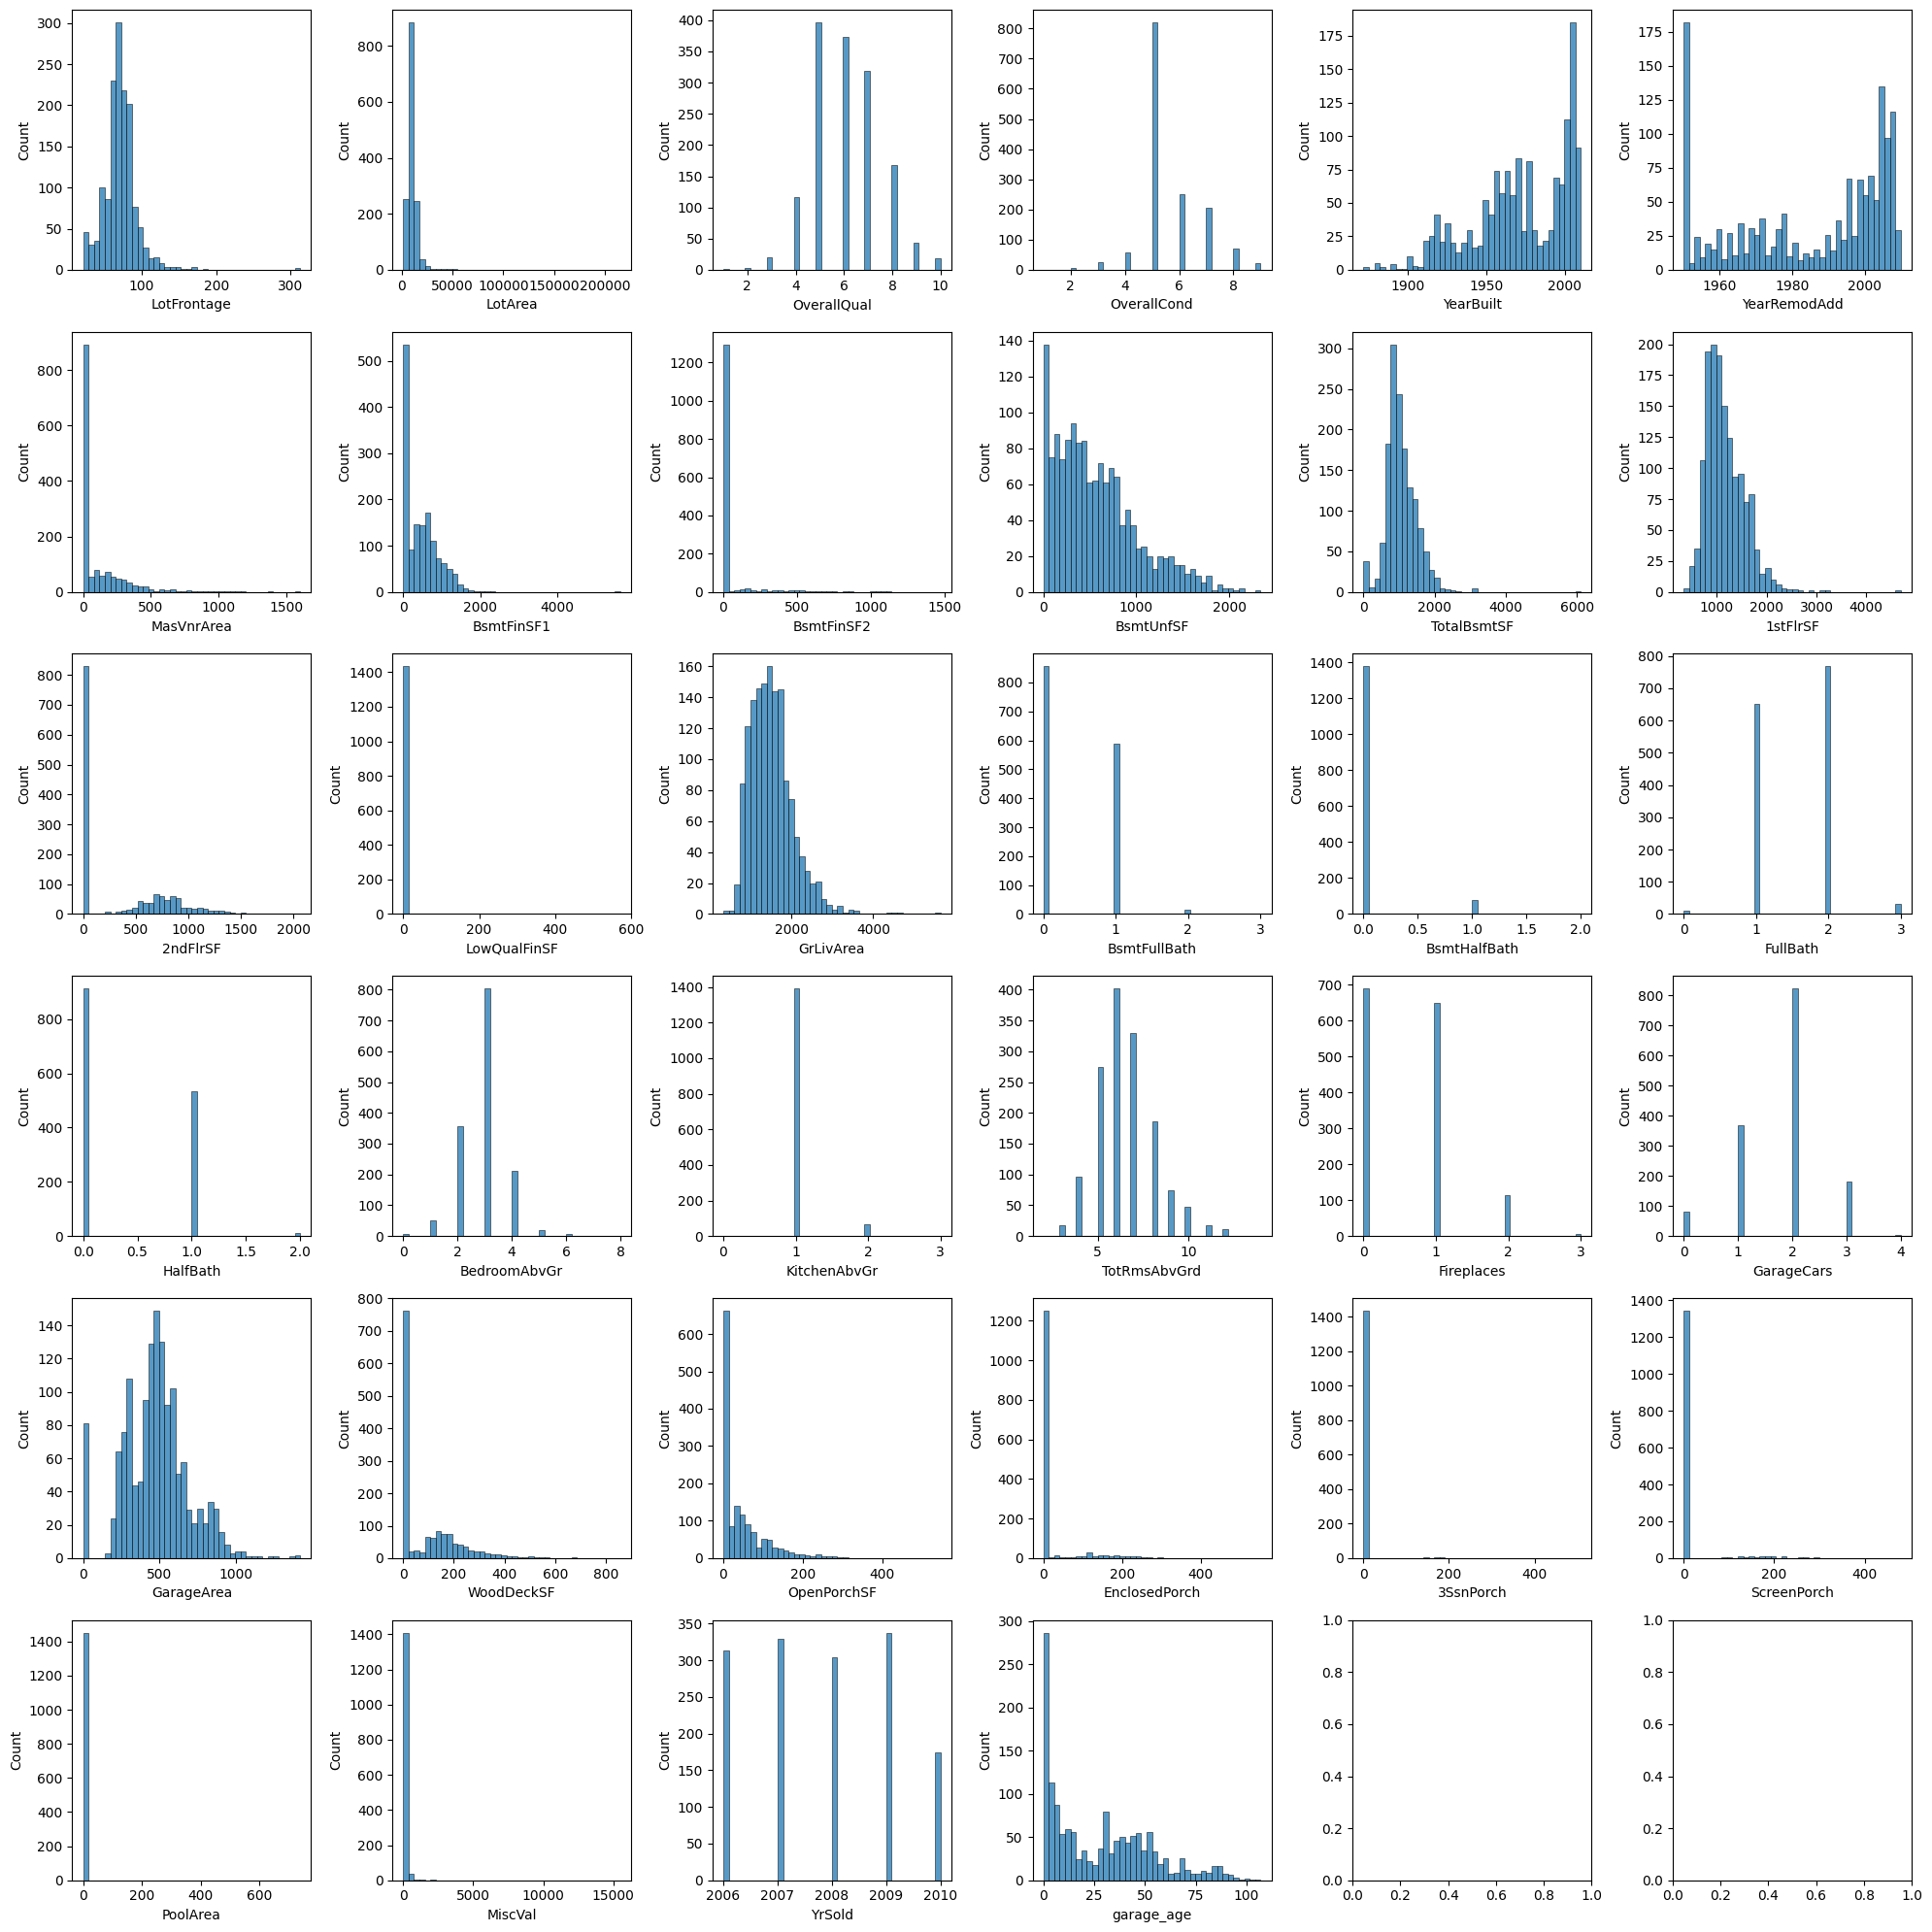

In [ ]:
# Plot numeric feature distributions in grid

fig, axes = plt.subplots(6, 6, sharex = False, sharey = False, figsize = (20, 20))

# Make looping easier
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins = 40, ax = axes[i])

plt.tight_layout()
plt.show()

Many heavily skewed features - implies tree based model will be more appropriate.

Many of these features can be converted to binary e.g. has_pool.

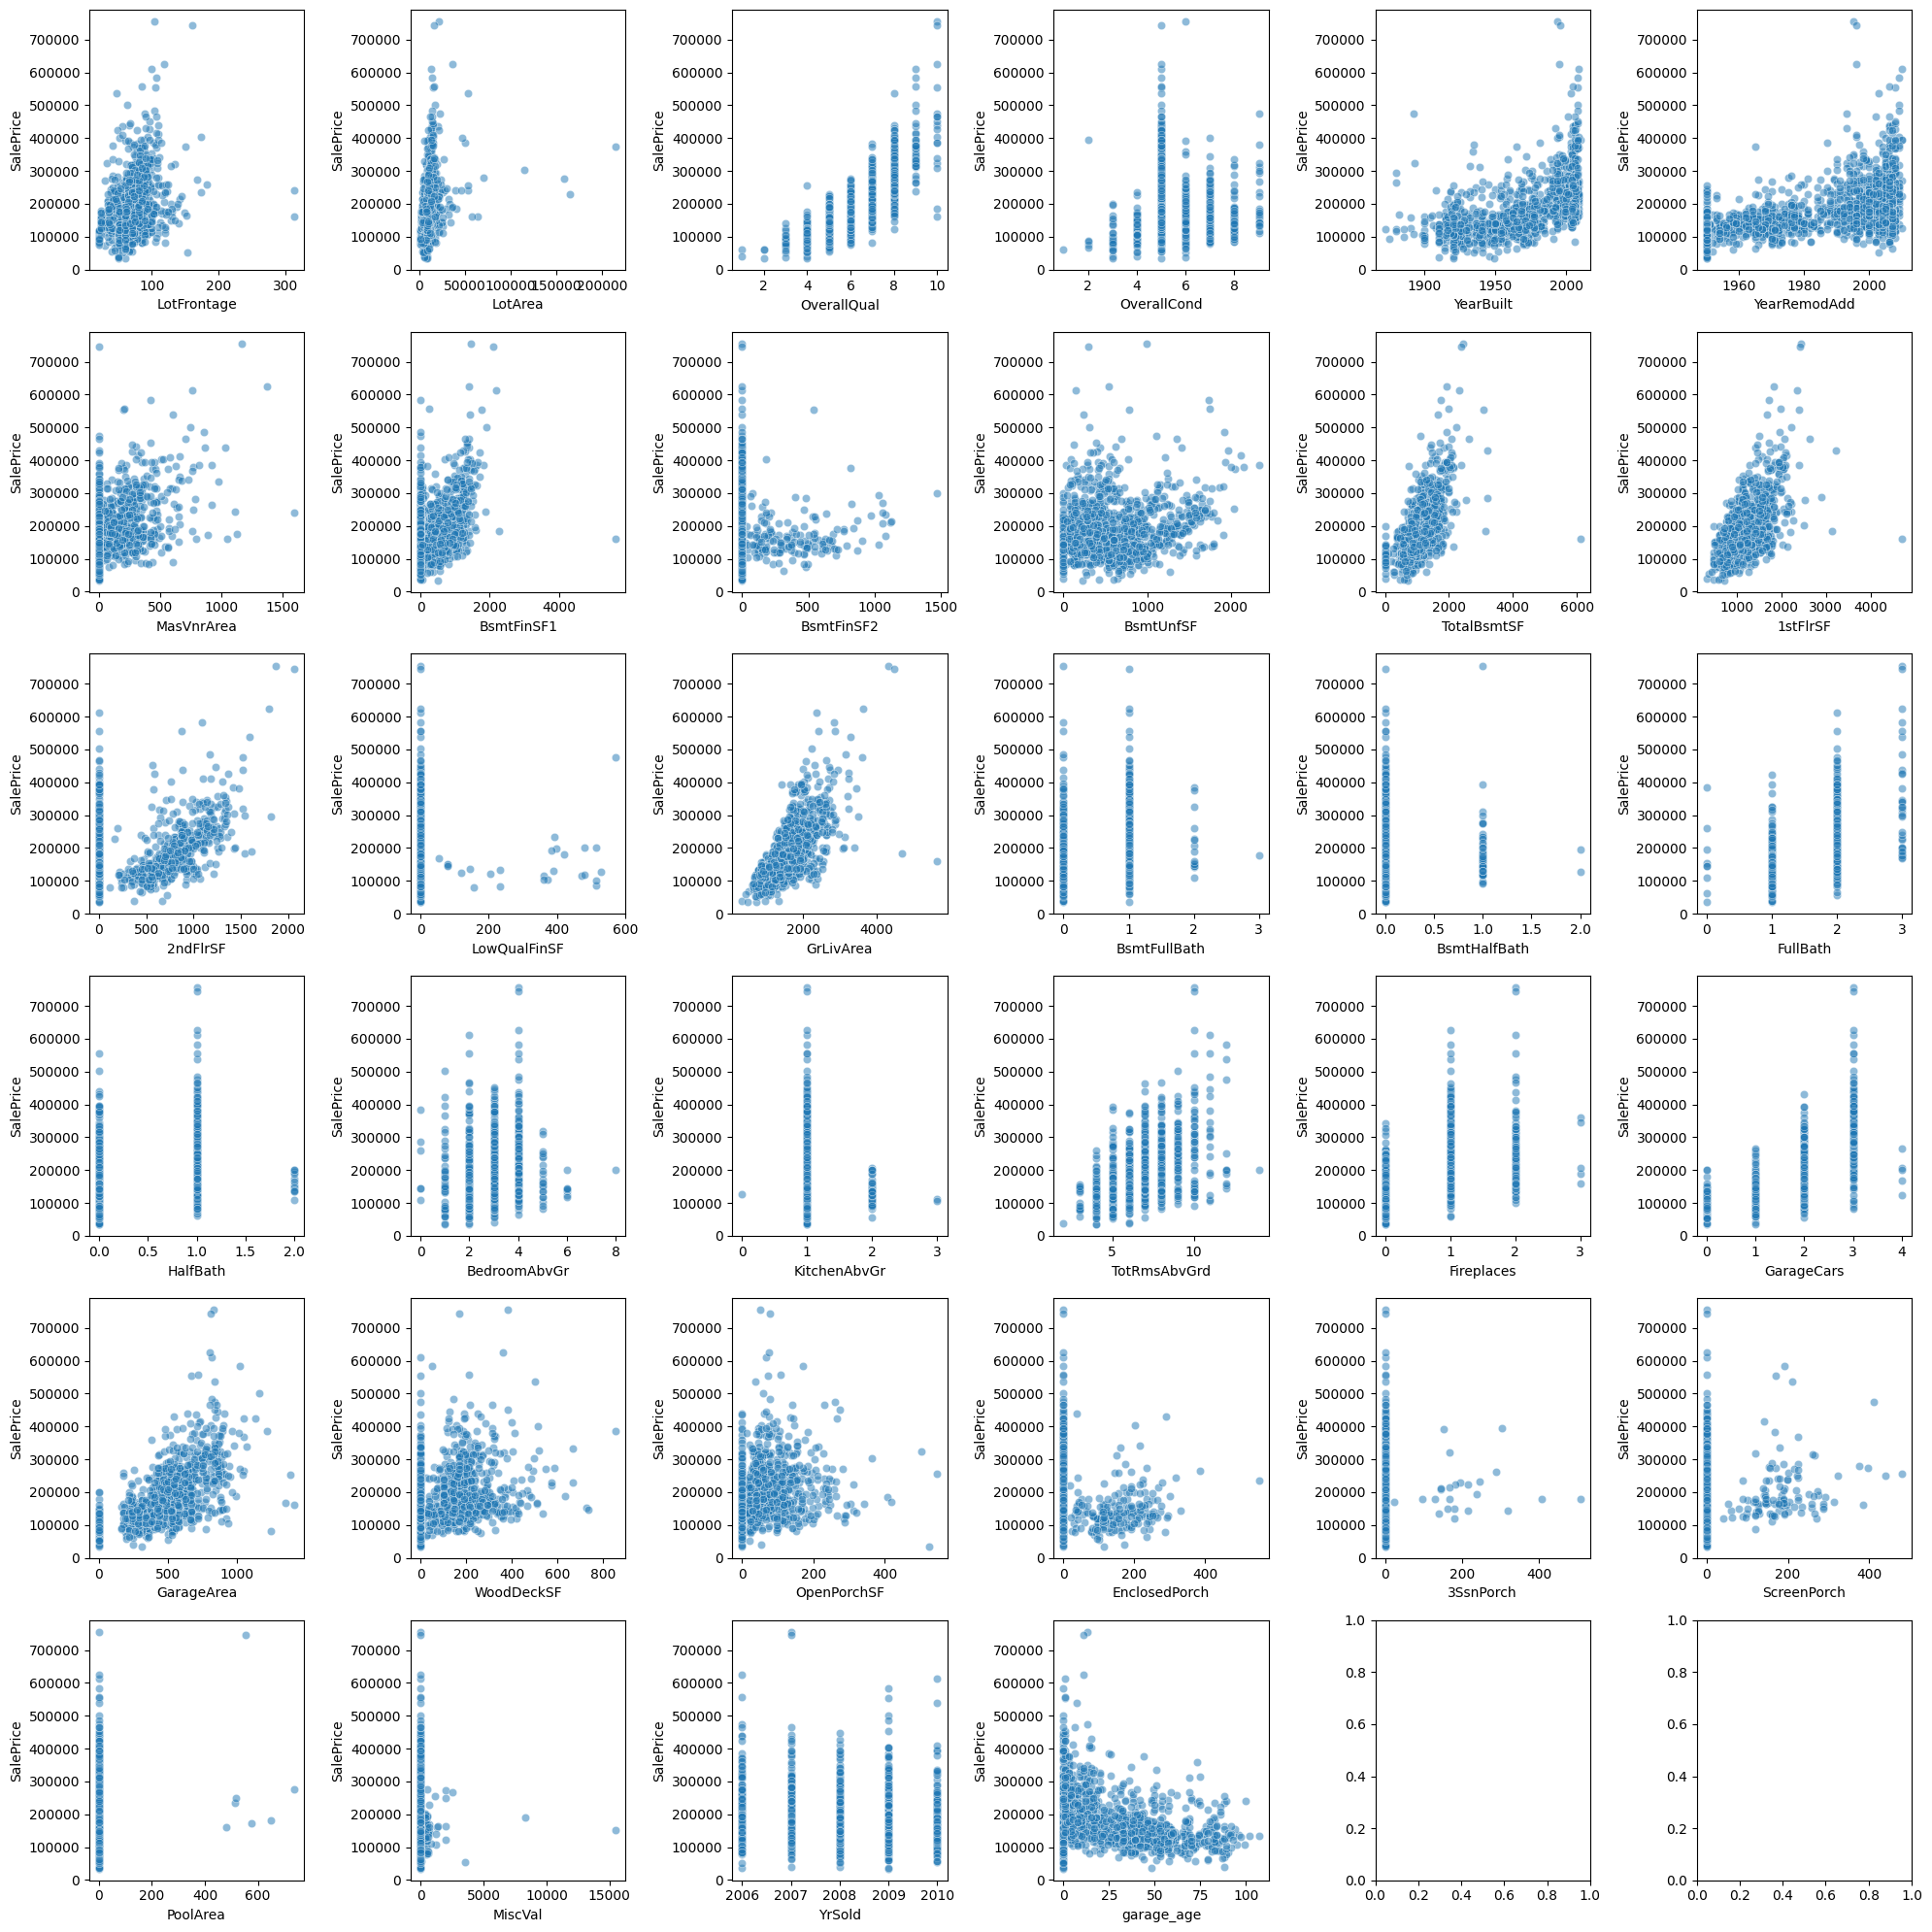

In [15]:
# Numeric features vs sale price

fig, axes = plt.subplots(6, 6, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(x=df[col], y=df["SalePrice"], alpha=0.5, ax = axes[i])

plt.tight_layout()
plt.show()

Evidence of outliers. Identify using table or scatterplot and remove.

In [16]:
# Look at GrLivArea outliers

df[["GrLivArea", "SalePrice"]].sort_values(by="GrLivArea", ascending=False).head()

,GrLivArea,SalePrice
Id,,
1299,5642,160000
524,4676,184750
1183,4476,745000
692,4316,755000
1170,3627,625000


In [17]:
# Look at MiscVal outliers

df[["MiscVal", "SalePrice"]].sort_values(by="MiscVal", ascending=False).head()

,MiscVal,SalePrice
Id,,
347,15500,151500
1231,8300,190000
706,3500,55000
1458,2500,266500
511,2000,164900


In [19]:
# Remove obvious outliers

df = df[
    (df["LotFrontage"] < 300) &
    (df["LotArea"] < 100000) &
    (df["BsmtFinSF1"] < 4000) &
    (df["TotalBsmtSF"] < 6000) &
    (df["GrLivArea"] < 4676) &
    (df["MiscVal"] < 8300) &
    (df["BedroomAbvGr"] < 8) &
    (df["LotArea"] < 70000) &
    (df["MasVnrArea"] < 1400) &
    (df["OpenPorchSF"] < 400)
]

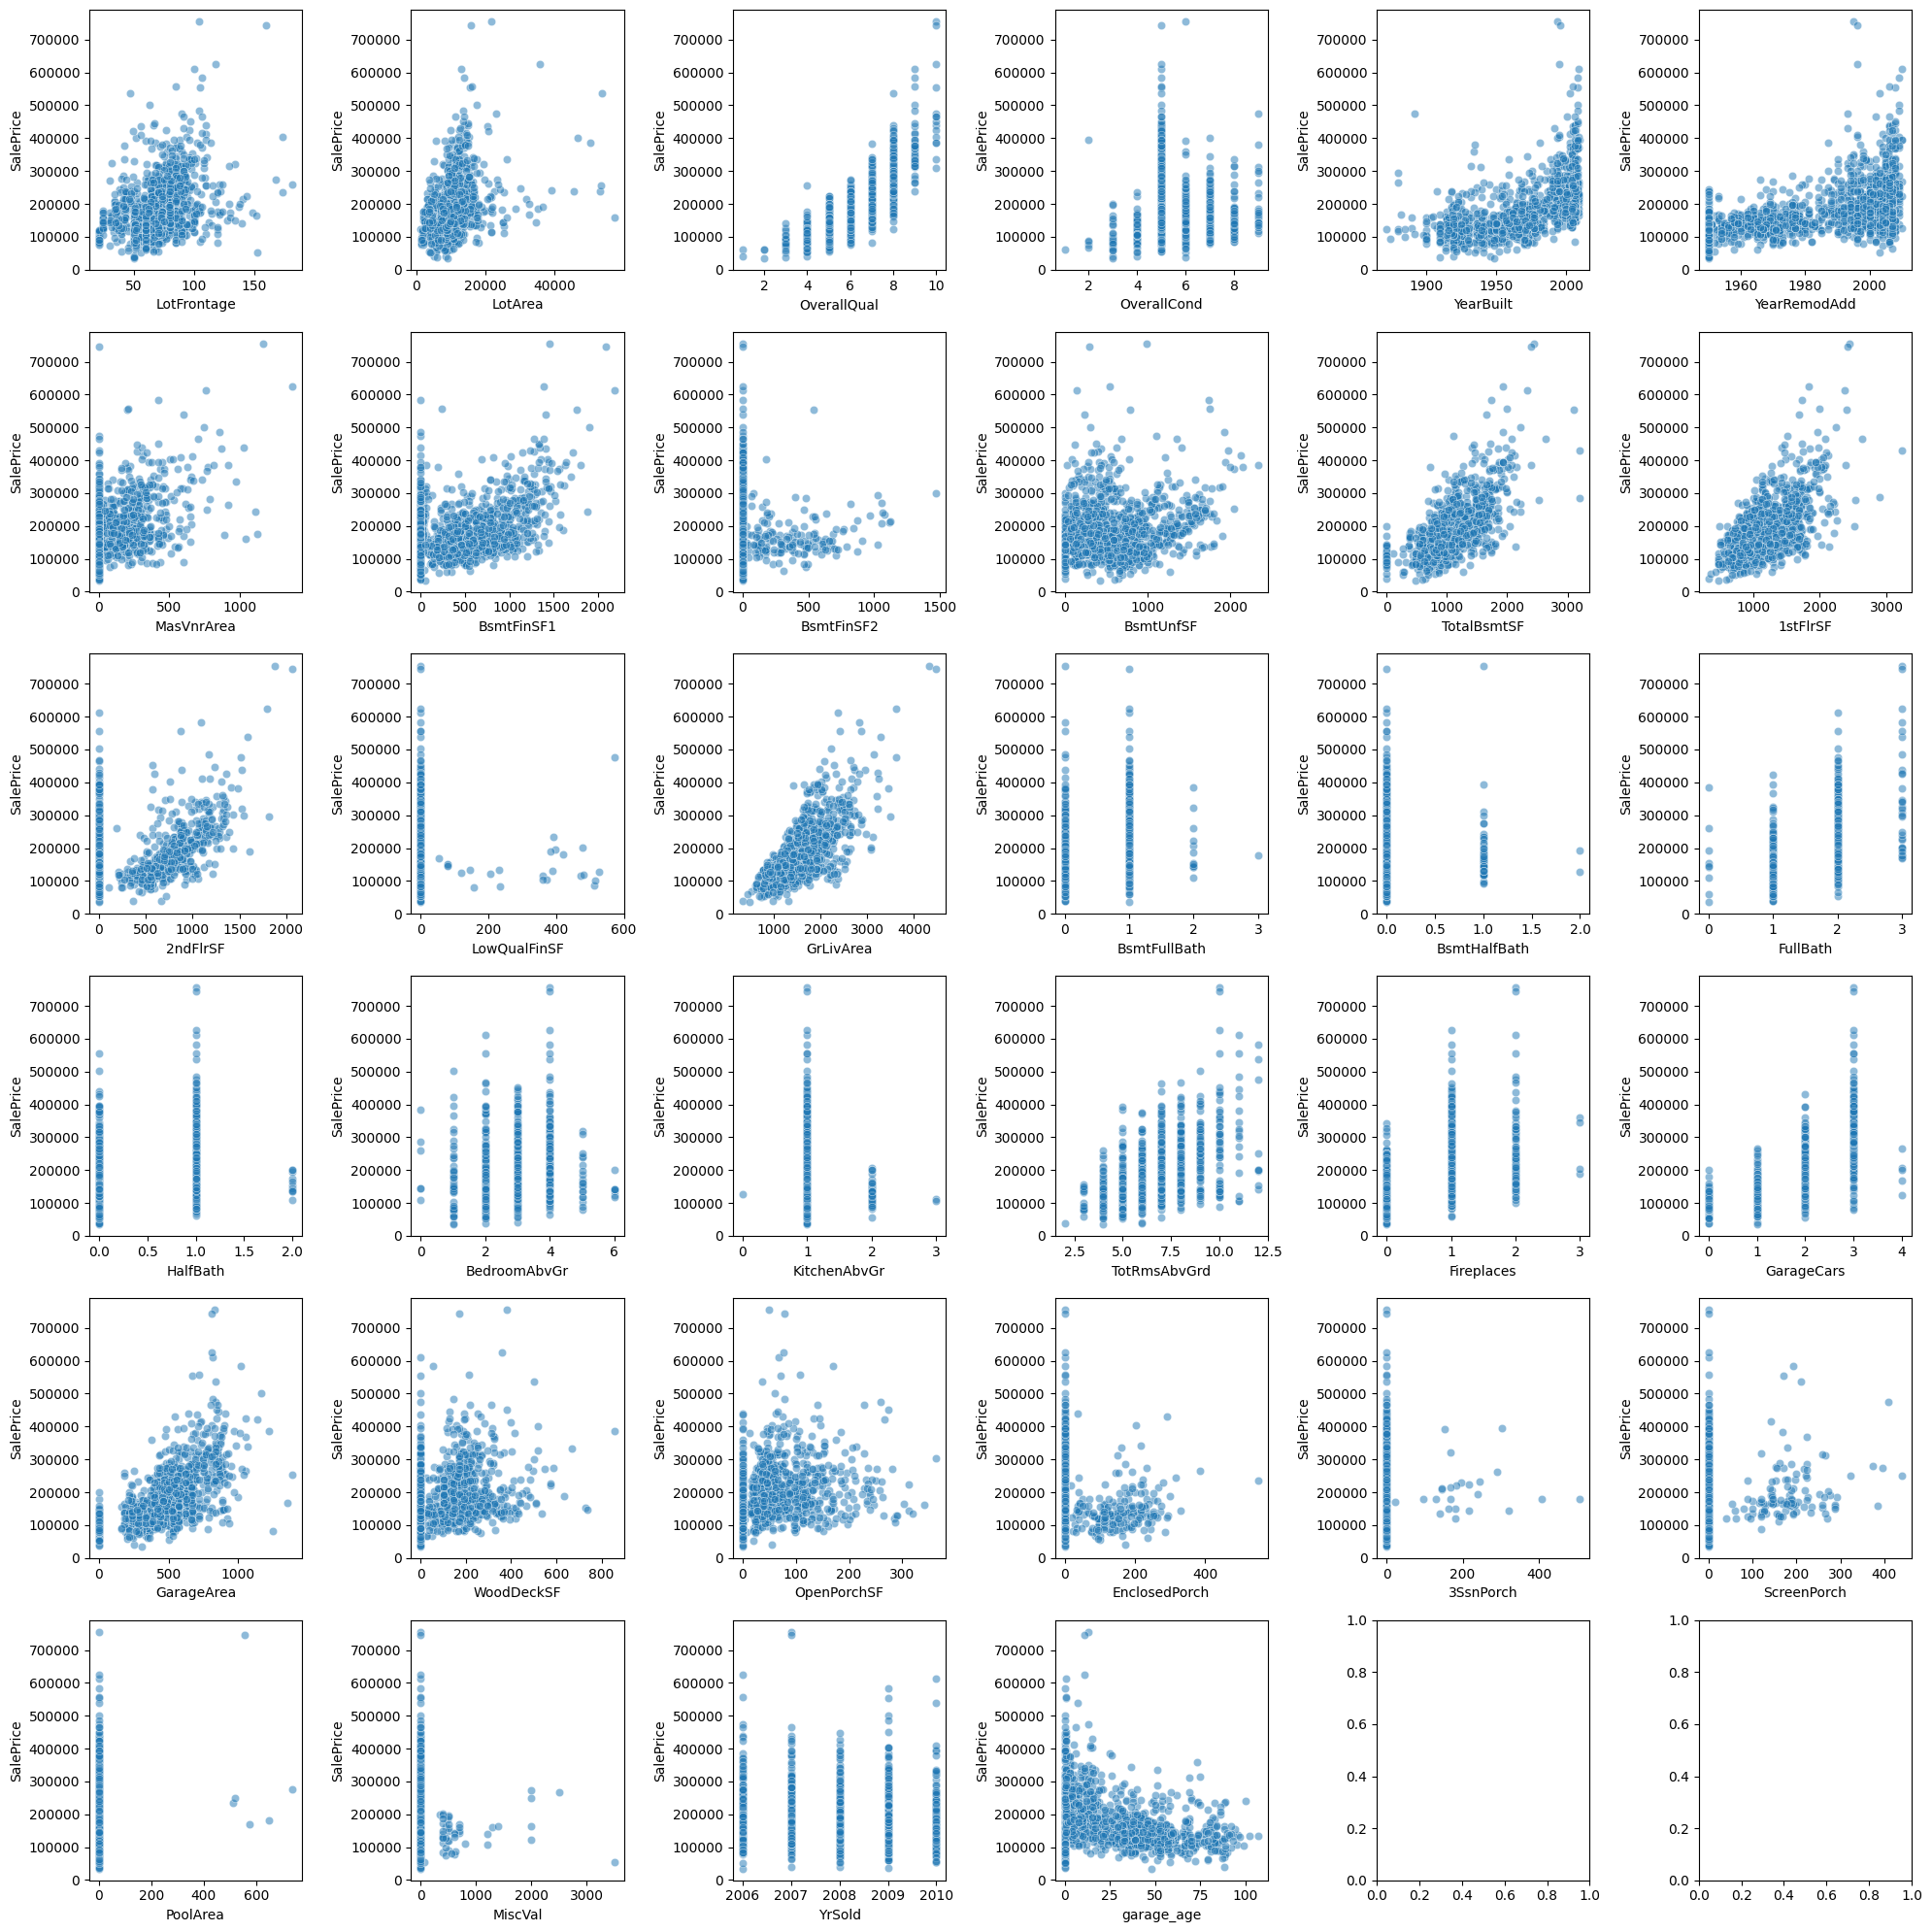

In [20]:
# Re check feature vs sale price after outlier removal

fig, axes = plt.subplots(6, 6, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(x=df[col], y=df["SalePrice"], alpha=0.5, ax = axes[i])

plt.tight_layout()
plt.show()

In [21]:
# Look at feature correlations to SalePrice

top_features = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

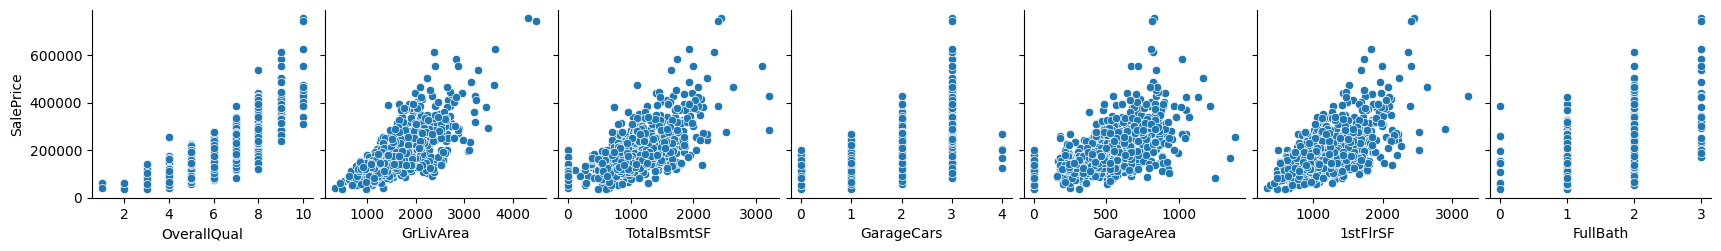

In [22]:
# Most correlated features vs Sale price

sns.pairplot(data=df, x_vars=top_features.index[1:8], y_vars=["SalePrice"])

This shows strongs relationships between these features and target. Next check least import features to confirm no relationship.

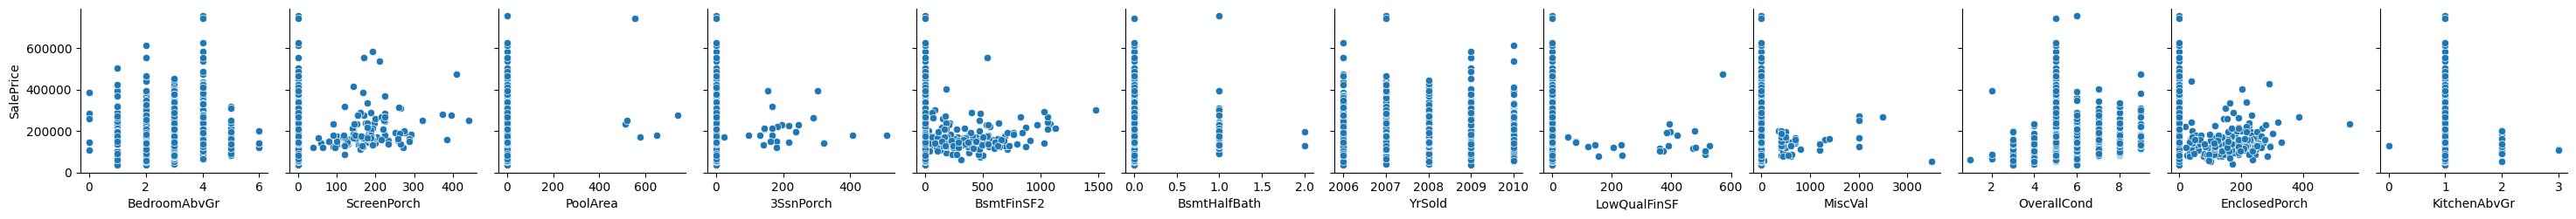

In [23]:
low_correlation_features = top_features[np.abs(top_features) < 0.2]

sns.pairplot(data=df, x_vars=low_correlation_features.index, y_vars=["SalePrice"])

<Axes: >

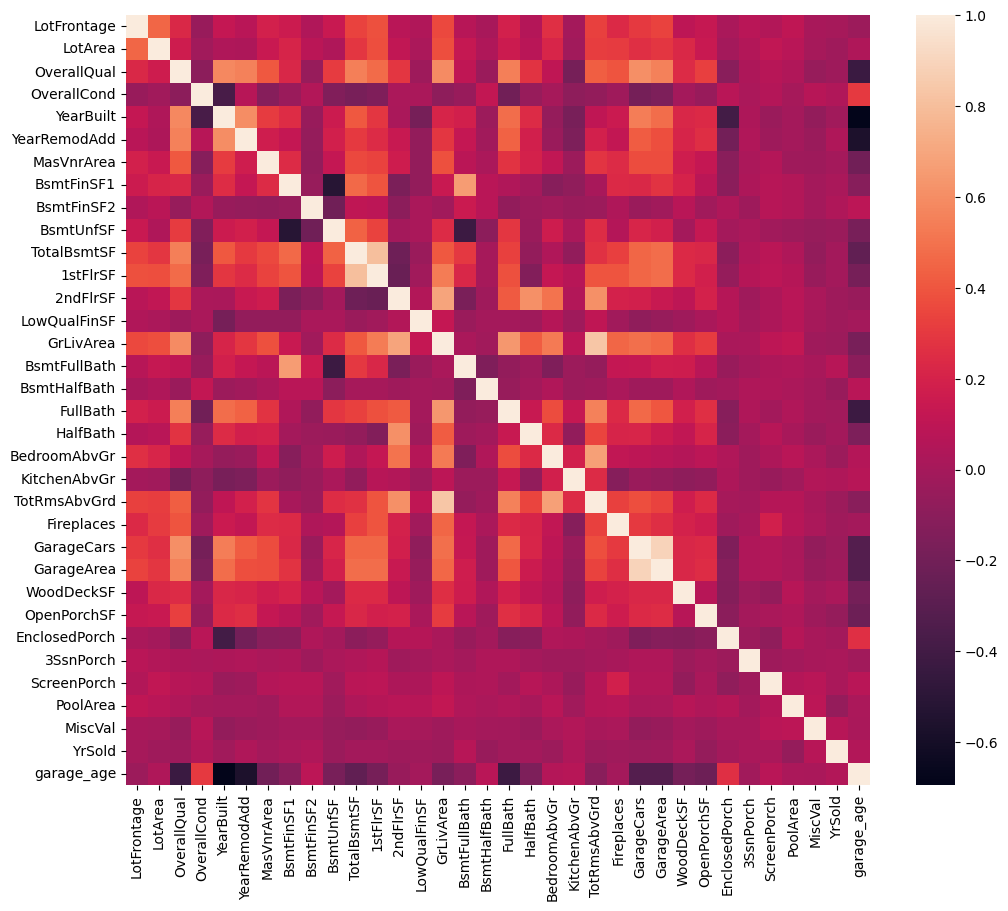

In [24]:
# Correlation matrix for numeric features

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr)

Many features are correlated, suggesting linear models are unsuitable without more detailed feature engineering/investigation.

**Numeric feature engineering**

In [25]:
cols_to_drop = []

Convert massively skewed features into binary where appropriate. Keep 2nd floor SF as still important feature.

In [26]:
# Feature convert to binary

df["has_second_floor"] = df["2ndFlrSF"]

features_to_binary = ["has_second_floor", "3SsnPorch", "ScreenPorch", "PoolArea", "EnclosedPorch"]

for col in features_to_binary:
    df[col] = df[col] > 0

In [27]:
# Create house_age

df["house_age"] = df["YrSold"] - df["YearBuilt"]

cols_to_drop.append("YrSold")
cols_to_drop.append("YearBuilt")

Remove features that clearly have no relationship with sale price or will negatively impact model performance.

In [34]:
# Drop unpredictable features

cols_to_drop.append("BedroomAbvGr")
cols_to_drop.append("BsmtFinSF2")
cols_to_drop.append("BsmtHalfBath")
cols_to_drop.append("LowQualFinSF")
cols_to_drop.append("MiscVal")
cols_to_drop.append("KitchenAbvGr")
cols_to_drop.append("BsmtFullBath")
cols_to_drop.append("HalfBath")

In [36]:
# Re check numeric features vs sale price after engineering

new_numeric_cols = df.drop(columns = ["SalePrice"] + cols_to_drop).select_dtypes(np.number).columns

len(new_numeric_cols)

21

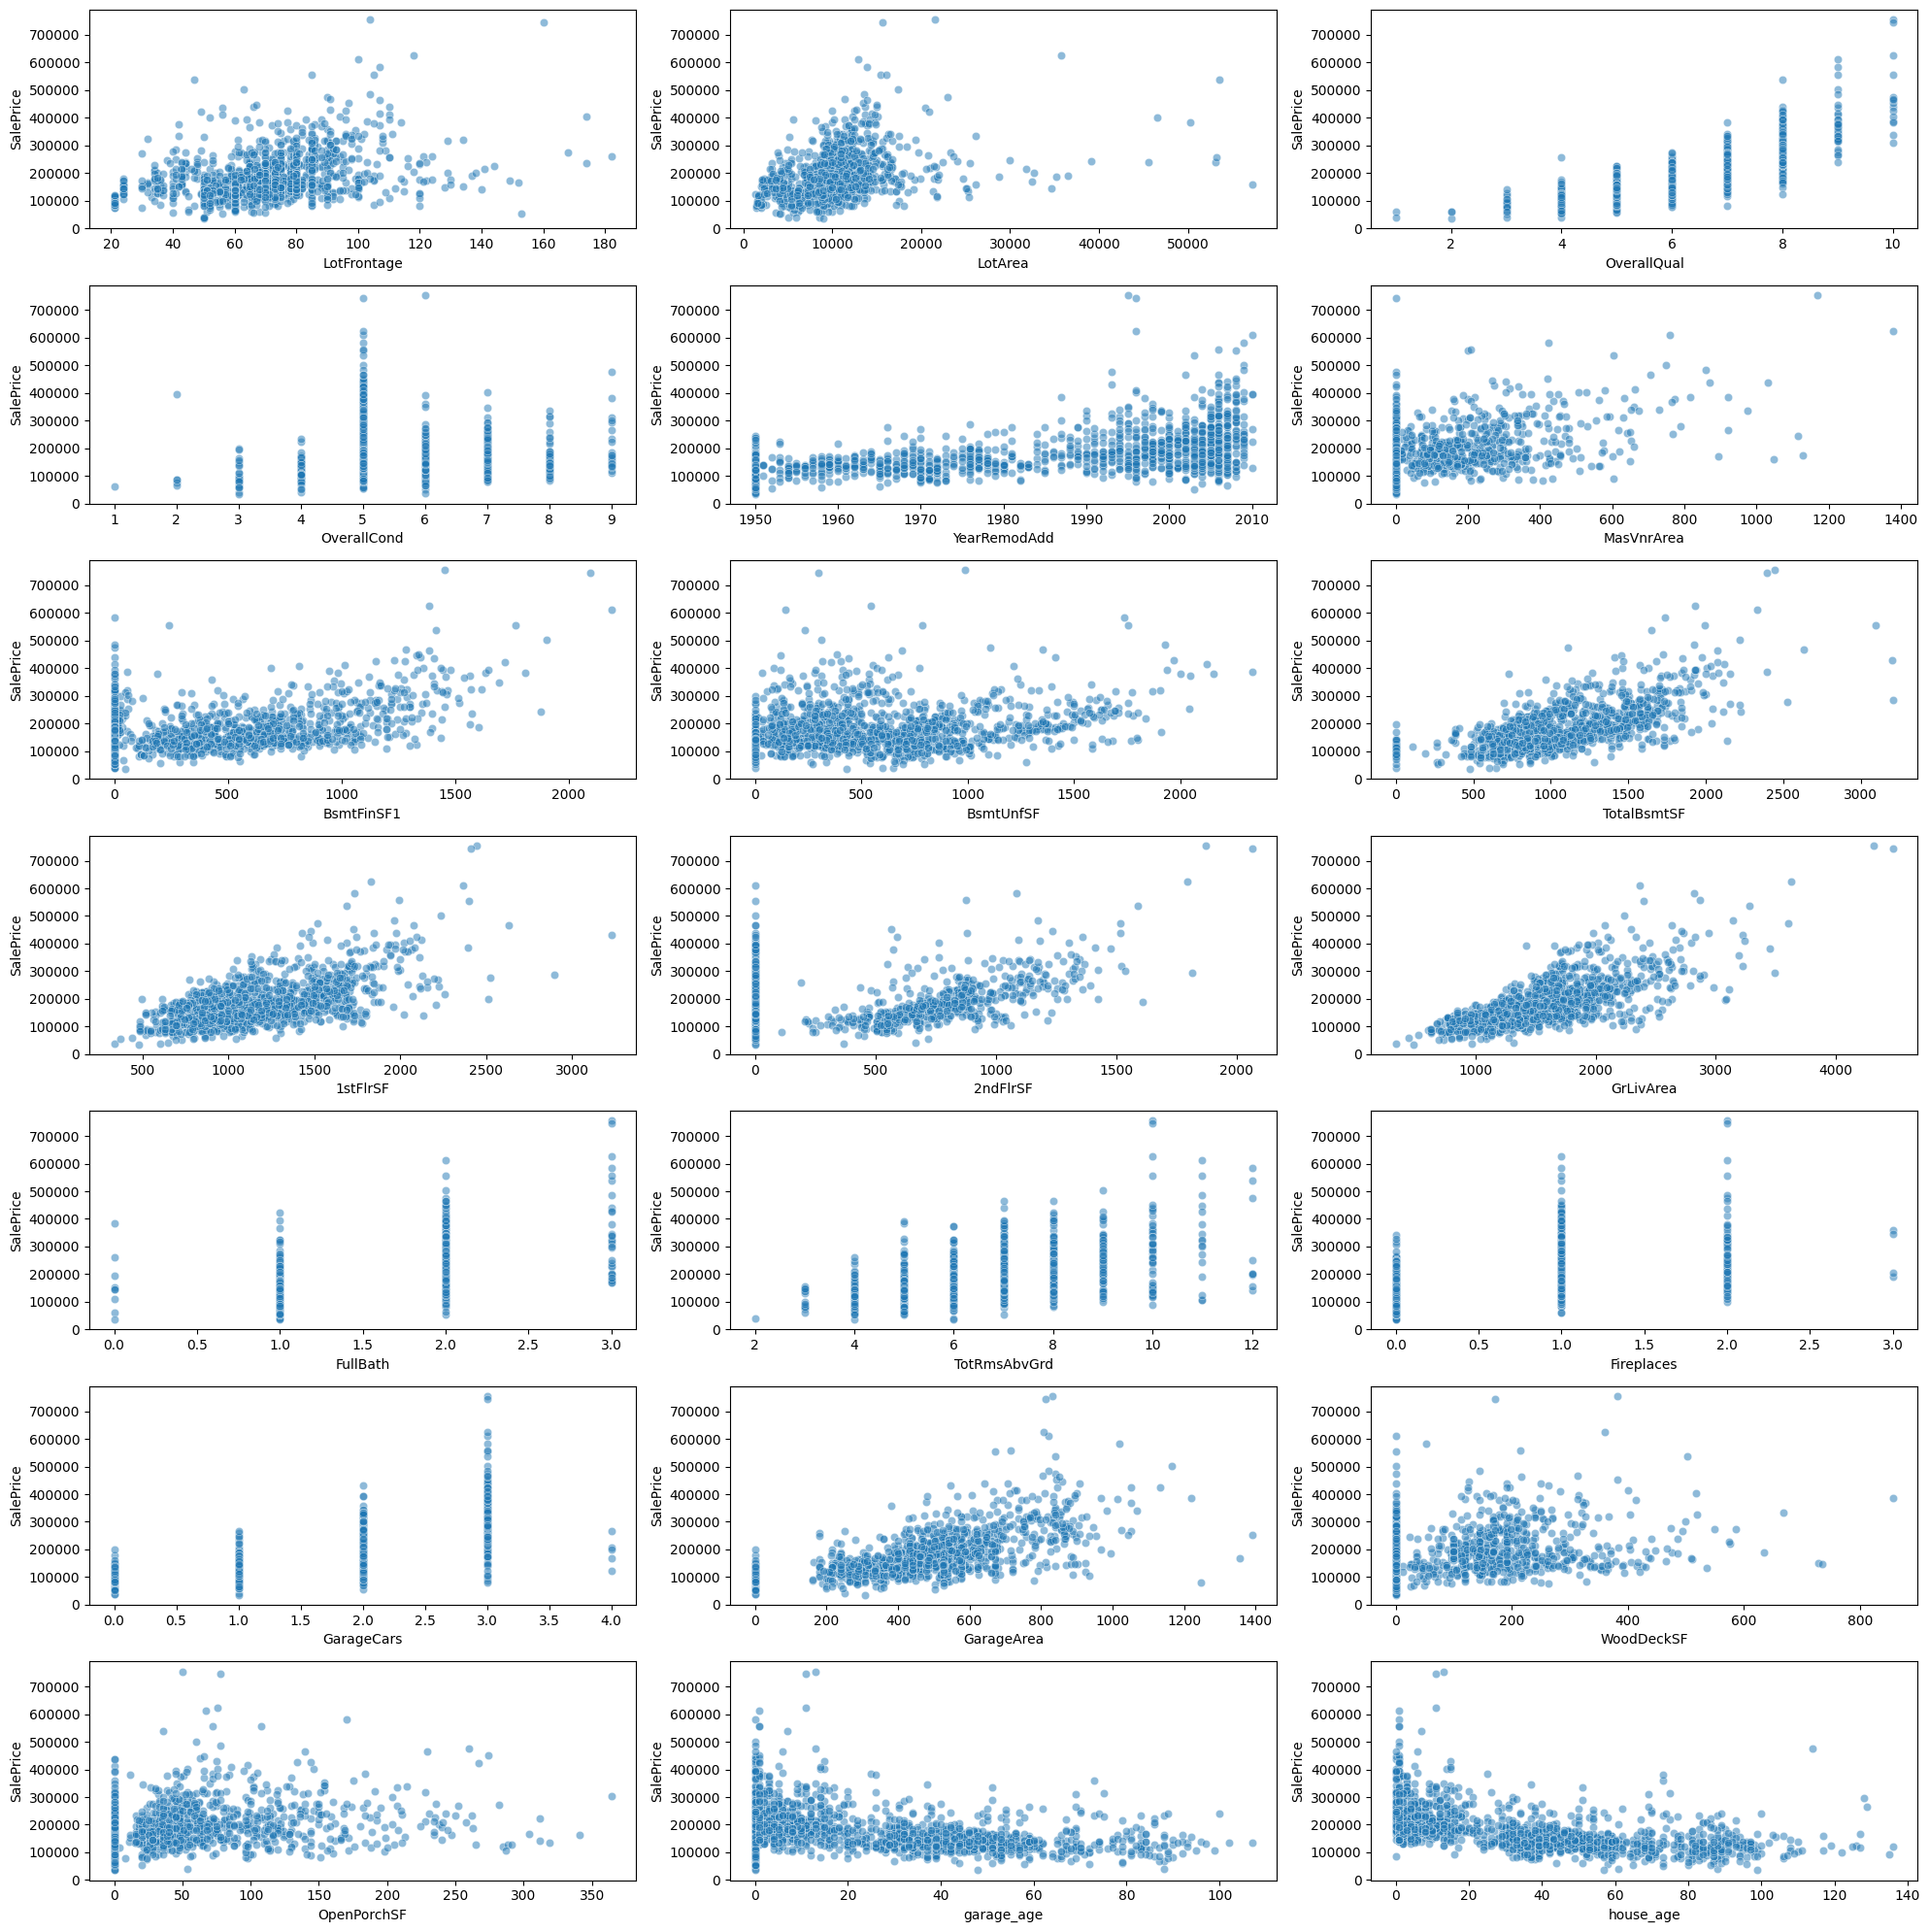

In [37]:
# Plot new numeric features vs sale price

fig, axes = plt.subplots(7, 3, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(new_numeric_cols):
    sns.scatterplot(x=df[col], y=df["SalePrice"], alpha=0.5, ax = axes[i])

plt.tight_layout()
plt.show()

**Categorical features**

In [33]:
# Look at categorical columns

cat_cols = df.select_dtypes(include=['object', 'category', 'str']).columns

print("Categorical columns: ", len(cat_cols))


Categorical columns:  45


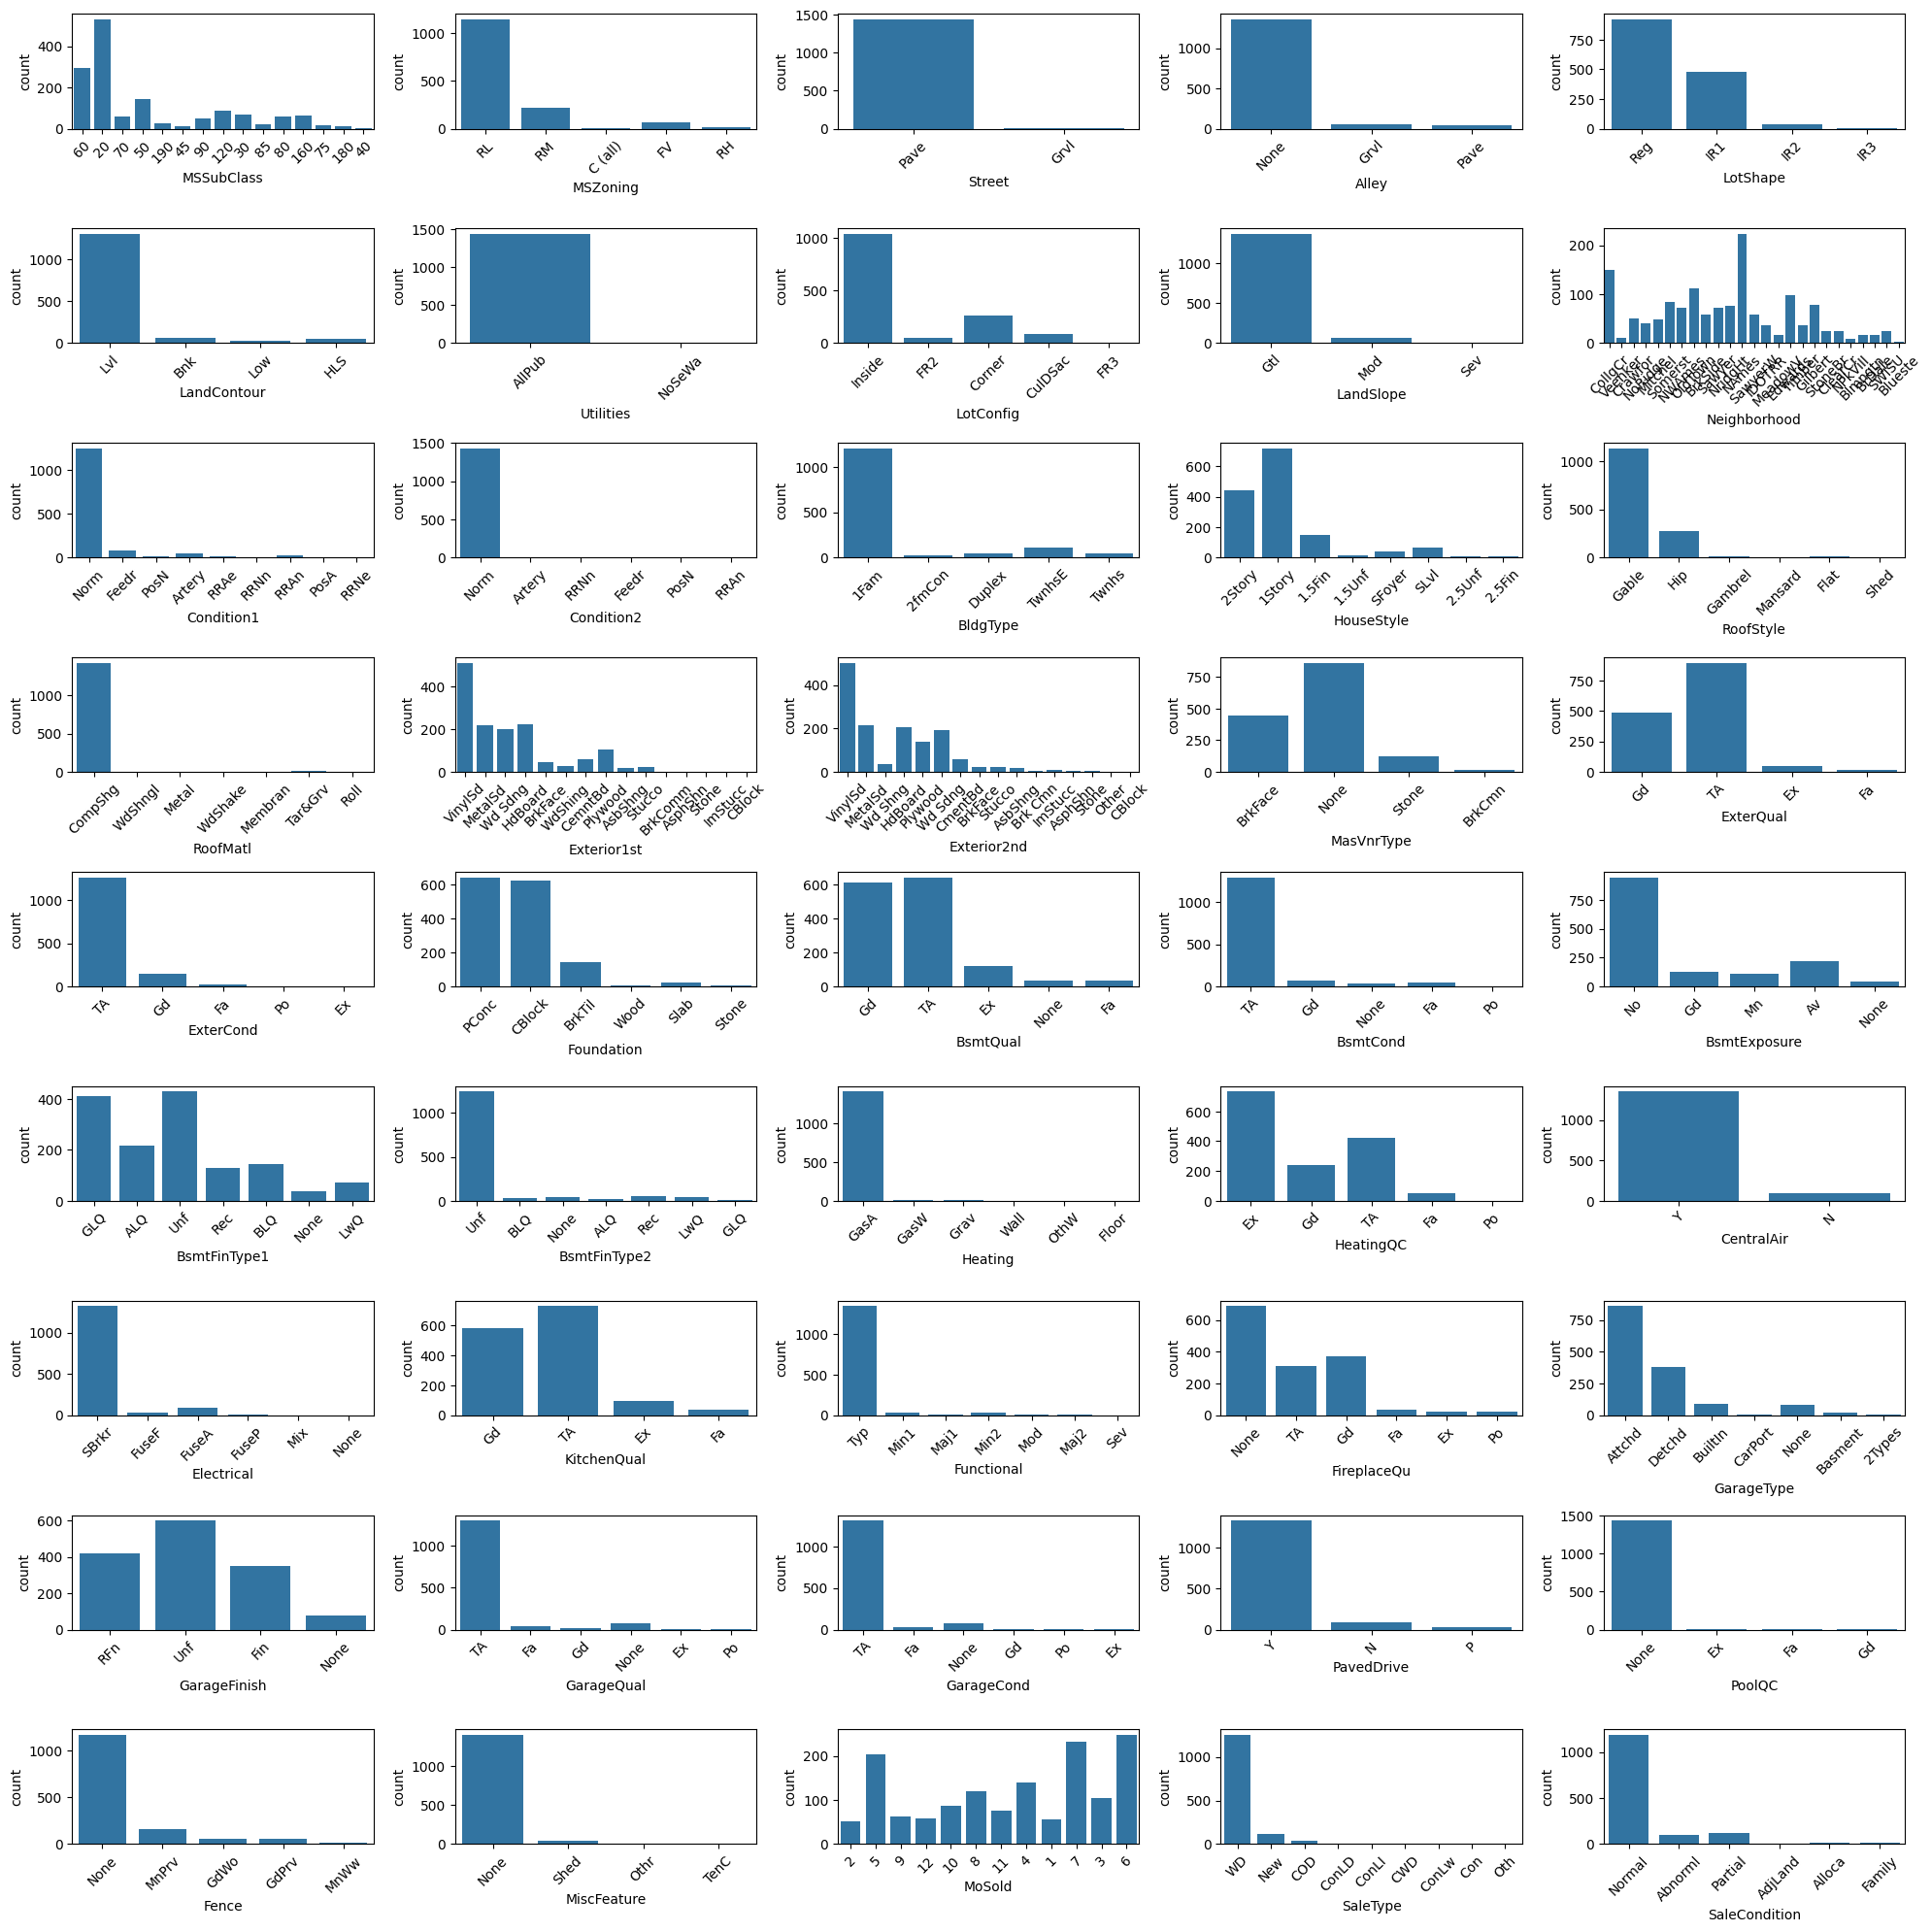

In [38]:
# Look at cat col distributions in grid

fig, axes = plt.subplots(9, 5, sharex = False, sharey = False, figsize = (20, 20))

# Make looping easier
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x = col, data = df, ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

Some features are massively skewed, check the boxplots for the categories and ANOVA if further inspection required.

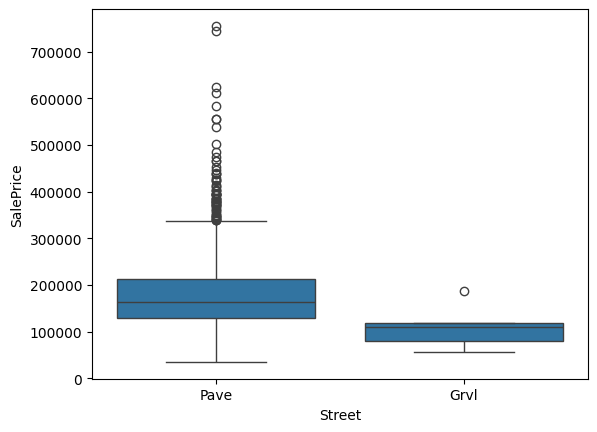

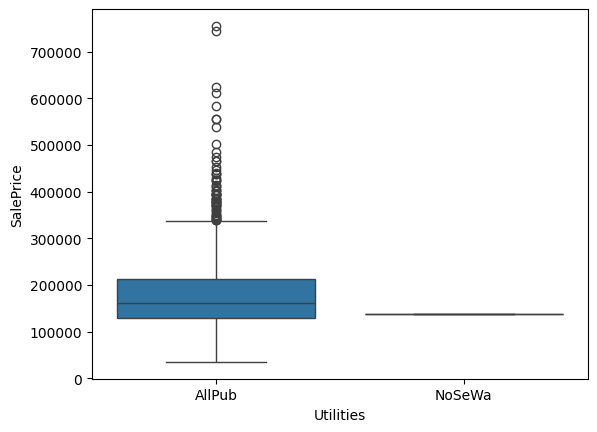

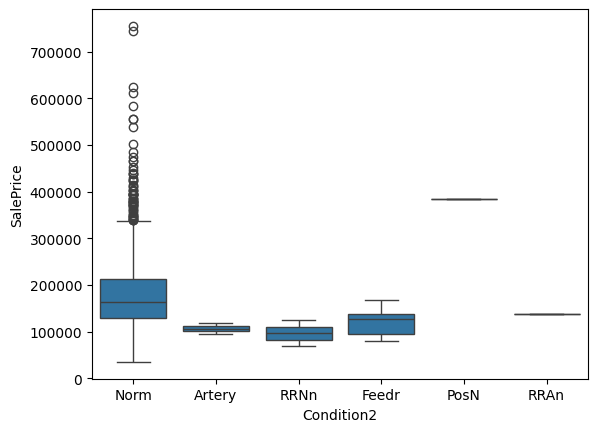

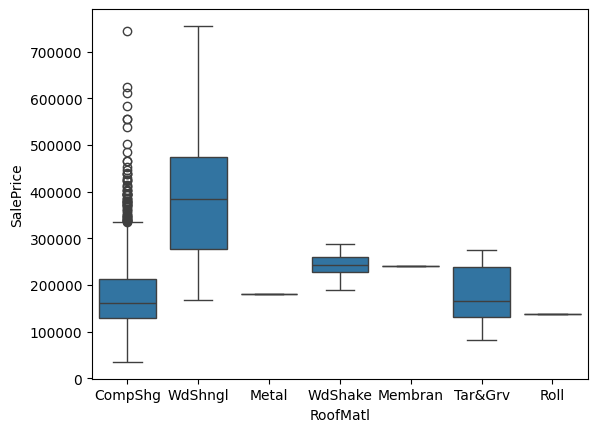

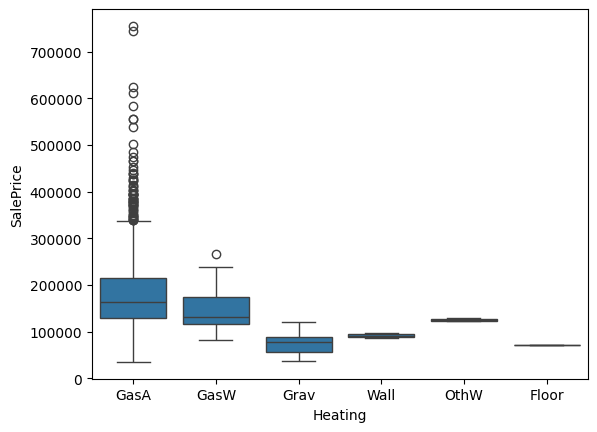

In [ ]:
# Boxplots for skewed cat_cols

cat_cols_to_check = ["Street", "Utilities", "Condition2", "RoofMatl", "Heating"]

for col in cat_cols_to_check:
    sns.boxplot(data = df, x = col, y = "SalePrice")
    plt.show()

In [68]:
# Utilities value counts

df["Utilities"].value_counts()

Utilities
AllPub    1443
NoSeWa       1
Name: count, dtype: int64

Drop utilities as clearly too imbalance.

In [69]:
cols_to_drop.append("Utilities")

**Model building**

In [74]:
# Import model and RMSE

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

In [82]:
# Split data for training and convert cat variables

X_train = pd.get_dummies(df.drop(columns=["SalePrice"] + cols_to_drop))

y_train = df["SalePrice"]

MUST CONVERT SALE PRICE TO LOG TRANSORM FIRST

In [83]:
# Initiate model and fit

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
# Load test data, does not include SalePrice

test = pd.read_csv("test.csv", index_col = "Id")

In [ ]:
# Pre process test data